# 4. Modèles Avancés (Deep Learning)

**Projet Semesteriel - Détection de Fake News COVID-19**  
**Niveau 4CS | Superviseur : Prof. Salem Trabelsi**

---

## Objectif

Ce notebook implémente des modèles de deep learning basés sur les Transformers :
- **BERT** (bert-base-uncased) - Modèle principal
- **DistilBERT** - Alternative plus légère
- **RoBERTa** - Variante optimisée de BERT

Nous comparons ces modèles avec les baselines du notebook précédent.

## 4.1 Importation des bibliothèques et configuration

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.optim import AdamW

from transformers import (
    BertTokenizer, BertForSequenceClassification,
    DistilBertTokenizer, DistilBertForSequenceClassification,
    RobertaTokenizer, RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.join('..', 'src'))

In [2]:
print(f"PyTorch version : {torch.__version__}")
print("Bibliotheques importees avec succes.")

PyTorch version : 2.11.0+cpu
Bibliotheques importees avec succes.


## 4.2 Configuration du device (GPU/CPU)

In [3]:
# Detecter le device optimal
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"GPU detecte : {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Apple Silicon MPS detecte.")
else:
    device = torch.device('cpu')
    print("Pas de GPU detecte. Utilisation du CPU.")

print(f"\nDevice utilise : {device}")

Pas de GPU detecte. Utilisation du CPU.

Device utilise : cpu


In [4]:
# Parametres optimises pour CPU
MAX_LENGTH = 64
BATCH_SIZE = 32
LEARNING_RATE = 3e-5
NUM_EPOCHS = 2
WARMUP_RATIO = 0.1

# Flags pour controler quels modeles entrainer
TRAIN_BERT = False      # Trop lent sur CPU (~15 min/epoch)
TRAIN_ROBERTA = False   # Trop lent sur CPU (~25 min/epoch)

print(f"\nHyperparametres (optimises CPU) :")
print(f"  MAX_LENGTH   : {MAX_LENGTH}")
print(f"  BATCH_SIZE   : {BATCH_SIZE}")
print(f"  LEARNING_RATE: {LEARNING_RATE}")
print(f"  NUM_EPOCHS   : {NUM_EPOCHS}")
print(f"  TRAIN_BERT   : {TRAIN_BERT}")
print(f"  TRAIN_ROBERTA: {TRAIN_ROBERTA}")


Hyperparametres (optimises CPU) :
  MAX_LENGTH   : 64
  BATCH_SIZE   : 32
  LEARNING_RATE: 3e-05
  NUM_EPOCHS   : 2
  TRAIN_BERT   : False
  TRAIN_ROBERTA: False


## 4.3 Chargement des données

In [5]:
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
MODELS_DIR = os.path.join('..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

# Charger les données prétraitées
df_train = pd.read_csv(os.path.join(PROCESSED_DIR, 'train_processed.csv'))
df_val = pd.read_csv(os.path.join(PROCESSED_DIR, 'val_processed.csv'))
df_test = pd.read_csv(os.path.join(PROCESSED_DIR, 'test_processed.csv'))

# Charger les métadonnées
with open(os.path.join(PROCESSED_DIR, 'metadata.json'), 'r') as f:
    metadata = json.load(f)

label_names = list(metadata['label_mapping'].keys())
num_labels = len(label_names)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print(f"Classes : {label_names}")
print(f"Nombre de classes : {num_labels}")

Train: 6420 | Val: 2140 | Test: 2140
Classes : ['fake', 'real']
Nombre de classes : 2


## 4.4 Préparation des données pour les Transformers

Création des datasets et dataloaders PyTorch.

In [6]:
class FakeNewsDataset(Dataset):
    """Dataset PyTorch pour la detection de fake news."""
    
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long)
        }


def create_data_loaders(tokenizer, batch_size=BATCH_SIZE, max_length=MAX_LENGTH):
    """Creer les dataloaders pour train/val/test."""
    train_dataset = FakeNewsDataset(
        df_train['cleaned_text'].fillna(''), df_train['label_encoded'],
        tokenizer, max_length
    )
    val_dataset = FakeNewsDataset(
        df_val['cleaned_text'].fillna(''), df_val['label_encoded'],
        tokenizer, max_length
    )
    test_dataset = FakeNewsDataset(
        df_test['cleaned_text'].fillna(''), df_test['label_encoded'],
        tokenizer, max_length
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

In [7]:
print("Classes FakeNewsDataset et create_data_loaders definies.")

Classes FakeNewsDataset et create_data_loaders definies.


## 4.5 Fonctions d'entraînement et d'évaluation

In [8]:
def train_epoch(model, data_loader, optimizer, scheduler, device):
    """Entraîner le modèle pour une époque."""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(data_loader, desc='Entraînement', leave=False)
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        total_loss += loss.item()
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return avg_loss, accuracy, f1


def evaluate(model, data_loader, device):
    """Évaluer le modèle."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Évaluation', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            total_loss += outputs.loss.item()
            
            probs = torch.softmax(outputs.logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return avg_loss, accuracy, f1, np.array(all_preds), np.array(all_labels), np.array(all_probs)

In [9]:
print("Fonctions d'entraînement et d'évaluation définies.")

Fonctions d'entraînement et d'évaluation définies.


In [10]:
def train_model(model, train_loader, val_loader, optimizer, scheduler, device, num_epochs, model_name='model'):
    """Boucle d'entraînement complète avec suivi des métriques."""
    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }
    
    best_val_f1 = 0
    best_model_state = None
    
    print(f"\n{'='*60}")
    print(f"ENTRAÎNEMENT : {model_name}")
    print(f"{'='*60}")
    
    for epoch in range(num_epochs):
        print(f"\n--- Époque {epoch + 1}/{num_epochs} ---")
        
        # Entraînement
        train_loss, train_acc, train_f1 = train_epoch(
            model, train_loader, optimizer, scheduler, device
        )
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        
        # Validation
        val_loss, val_acc, val_f1, _, _, _ = evaluate(model, val_loader, device)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        print(f"  Train - Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"  Val   - Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        
        # Sauvegarder le meilleur modèle
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = model.state_dict().copy()
            print(f"  => Nouveau meilleur modèle ! (F1: {best_val_f1:.4f})")
    
    # Restaurer le meilleur modèle
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return history, best_val_f1

In [11]:
print("Fonction train_model définie.")

Fonction train_model définie.


## 4.6 Fine-tuning de BERT (bert-base-uncased)

### Stratégie de fine-tuning :
1. Charger le modèle pré-entraîné
2. Geler les couches inférieures (optionnel)
3. Utiliser AdamW avec learning rate 2e-5
4. Warm-up linéaire du learning rate

In [12]:
if TRAIN_BERT:
    print("=" * 60)
    print("CHARGEMENT DE BERT (bert-base-uncased)")
    print("=" * 60)
    bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    bert_model = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased', num_labels=num_labels
    )
    bert_model = bert_model.to(device)
    total_params = sum(p.numel() for p in bert_model.parameters())
    trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
    print(f"\nParametres totaux    : {total_params:,}")
    print(f"Parametres entraines : {trainable_params:,}")
else:
    print("BERT : entainement ignore (TRAIN_BERT=False)")
    print("BERT est trop lent sur CPU (~15 min/epoch, 110M parametres)")
    print("Nous utilisons DistilBERT comme alternative plus efficace.")
    bert_model = None
    bert_tokenizer = None

BERT : entainement ignore (TRAIN_BERT=False)
BERT est trop lent sur CPU (~15 min/epoch, 110M parametres)
Nous utilisons DistilBERT comme alternative plus efficace.


In [13]:
if TRAIN_BERT and bert_model is not None:
    FREEZE_LAYERS = True
    FREEZE_N_LAYERS = 6
    if FREEZE_LAYERS:
        for param in bert_model.bert.embeddings.parameters():
            param.requires_grad = False
        for i in range(FREEZE_N_LAYERS):
            for param in bert_model.bert.encoder.layer[i].parameters():
                param.requires_grad = False
        trainable_after = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
        total_params = sum(p.numel() for p in bert_model.parameters())
        print(f"Apres gel de {FREEZE_N_LAYERS} couches :")
        print(f"  Parametres entraines : {trainable_after:,} ({trainable_after/total_params*100:.1f}%)")
else:
    print("BERT non charge - etape de gel ignoree.")

BERT non charge - etape de gel ignoree.


In [14]:
if TRAIN_BERT and bert_model is not None:
    bert_train_loader, bert_val_loader, bert_test_loader = create_data_loaders(
        bert_tokenizer, batch_size=BATCH_SIZE, max_length=MAX_LENGTH
    )
    bert_optimizer = AdamW(
        filter(lambda p: p.requires_grad, bert_model.parameters()),
        lr=LEARNING_RATE, weight_decay=0.01, eps=1e-8
    )
    total_steps = len(bert_train_loader) * NUM_EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    bert_scheduler = get_linear_schedule_with_warmup(
        bert_optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )
    print(f"Total steps : {total_steps}")
    print(f"Warmup steps : {warmup_steps}")
else:
    print("BERT : dataloader non cree (TRAIN_BERT=False)")

BERT : dataloader non cree (TRAIN_BERT=False)


In [15]:
if TRAIN_BERT and bert_model is not None:
    t0 = time()
    bert_history, bert_best_f1 = train_model(
        bert_model, bert_train_loader, bert_val_loader,
        bert_optimizer, bert_scheduler, device,
        num_epochs=NUM_EPOCHS, model_name='BERT'
    )
    bert_train_time = time() - t0
    print(f"\nTemps d\'entrainement BERT : {bert_train_time/60:.1f} minutes")
    print(f"Meilleur F1 sur validation : {bert_best_f1:.4f}")
else:
    bert_history = None
    bert_best_f1 = 0
    bert_train_time = 0
    print("BERT : entrainement ignore.")

BERT : entrainement ignore.


## 4.7 Fine-tuning de DistilBERT (alternative légère)

DistilBERT est une version distillée de BERT : 40% plus petit, 60% plus rapide, conservant 97% des performances.

In [16]:
print("=" * 60)
print("CHARGEMENT DE DistilBERT")
print("=" * 60)

distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
distilbert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)
distilbert_model = distilbert_model.to(device)

total_params_db = sum(p.numel() for p in distilbert_model.parameters())
print(f"Parametres DistilBERT : {total_params_db:,}")

# Geler les couches pour accelerer sur CPU
for param in distilbert_model.distilbert.embeddings.parameters():
    param.requires_grad = False

for i in range(5):  # Geler les 5 premieres couches (sur 6)
    for param in distilbert_model.distilbert.transformer.layer[i].parameters():
        param.requires_grad = False

trainable_db = sum(p.numel() for p in distilbert_model.parameters() if p.requires_grad)
print(f"Parametres entrainables : {trainable_db:,} ({trainable_db/total_params_db*100:.1f}%)")
print("Strategie : seule la derniere couche transformer + classifier sont entraines")

CHARGEMENT DE DistilBERT


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parametres DistilBERT : 66,955,010
Parametres entrainables : 7,680,002 (11.5%)
Strategie : seule la derniere couche transformer + classifier sont entraines


In [17]:
db_train_loader, db_val_loader, db_test_loader = create_data_loaders(
    distilbert_tokenizer, batch_size=BATCH_SIZE, max_length=MAX_LENGTH
)

db_optimizer = AdamW(
    filter(lambda p: p.requires_grad, distilbert_model.parameters()),
    lr=LEARNING_RATE, weight_decay=0.01, eps=1e-8
)

db_total_steps = len(db_train_loader) * NUM_EPOCHS
db_warmup_steps = int(db_total_steps * WARMUP_RATIO)

db_scheduler = get_linear_schedule_with_warmup(
    db_optimizer,
    num_warmup_steps=db_warmup_steps,
    num_training_steps=db_total_steps
)

In [18]:
# Entrainer DistilBERT
t0 = time()
db_history, db_best_f1 = train_model(
    distilbert_model, db_train_loader, db_val_loader,
    db_optimizer, db_scheduler, device,
    num_epochs=NUM_EPOCHS, model_name='DistilBERT'
)
db_train_time = time() - t0

print(f"\nTemps d\'entrainement DistilBERT : {db_train_time/60:.1f} minutes")
print(f"Meilleur F1 sur validation : {db_best_f1:.4f}")


ENTRAÎNEMENT : DistilBERT

--- Époque 1/2 ---


Entraînement:   0%|          | 0/201 [00:00<?, ?it/s]

Évaluation:   0%|          | 0/67 [00:00<?, ?it/s]

  Train - Loss: 0.3920 | Acc: 0.8245 | F1: 0.8245
  Val   - Loss: 0.2441 | Acc: 0.9028 | F1: 0.9029
  => Nouveau meilleur modèle ! (F1: 0.9029)

--- Époque 2/2 ---


Entraînement:   0%|          | 0/201 [00:00<?, ?it/s]

Évaluation:   0%|          | 0/67 [00:00<?, ?it/s]

  Train - Loss: 0.2310 | Acc: 0.9087 | F1: 0.9087
  Val   - Loss: 0.2266 | Acc: 0.9098 | F1: 0.9099
  => Nouveau meilleur modèle ! (F1: 0.9099)

Temps d'entrainement DistilBERT : 6.6 minutes
Meilleur F1 sur validation : 0.9099


## 4.8 Fine-tuning de RoBERTa (optionnel)

RoBERTa est une version optimisée de BERT avec un pré-entraînement plus robuste.

In [19]:
print("RoBERTa : entrainement ignore (TRAIN_ROBERTA=False)")
print("RoBERTa est trop lent sur CPU (~25 min/epoch, 125M parametres)")
roberta_model = None
rb_history = None

RoBERTa : entrainement ignore (TRAIN_ROBERTA=False)
RoBERTa est trop lent sur CPU (~25 min/epoch, 125M parametres)


## 4.9 Courbes d'apprentissage

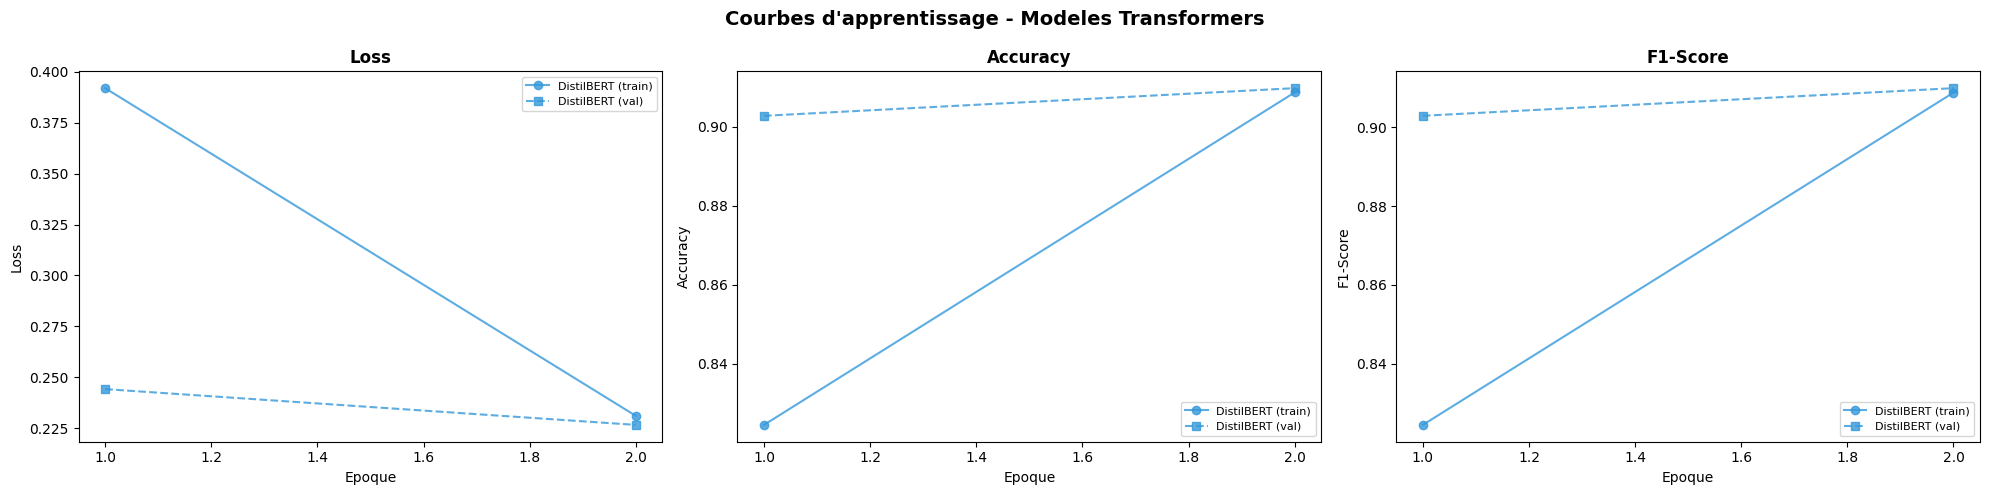

In [20]:
# Courbes d'apprentissage
histories = {}
if bert_history is not None:
    histories['BERT'] = bert_history
histories['DistilBERT'] = db_history
if rb_history is not None:
    histories['RoBERTa'] = rb_history

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors_models = ['#3498db', '#e67e22', '#9b59b6']

for idx_m, (name, history) in enumerate(histories.items()):
    color = colors_models[idx_m % len(colors_models)]
    epochs = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs, history['train_loss'], '-o', color=color, label=f'{name} (train)', alpha=0.8)
    axes[0].plot(epochs, history['val_loss'], '--s', color=color, label=f'{name} (val)', alpha=0.8)
    axes[1].plot(epochs, history['train_acc'], '-o', color=color, label=f'{name} (train)', alpha=0.8)
    axes[1].plot(epochs, history['val_acc'], '--s', color=color, label=f'{name} (val)', alpha=0.8)
    axes[2].plot(epochs, history['train_f1'], '-o', color=color, label=f'{name} (train)', alpha=0.8)
    axes[2].plot(epochs, history['val_f1'], '--s', color=color, label=f'{name} (val)', alpha=0.8)

axes[0].set_title('Loss', fontweight='bold'); axes[0].set_xlabel('Epoque'); axes[0].set_ylabel('Loss'); axes[0].legend(fontsize=8)
axes[1].set_title('Accuracy', fontweight='bold'); axes[1].set_xlabel('Epoque'); axes[1].set_ylabel('Accuracy'); axes[1].legend(fontsize=8)
axes[2].set_title('F1-Score', fontweight='bold'); axes[2].set_xlabel('Epoque'); axes[2].set_ylabel('F1-Score'); axes[2].legend(fontsize=8)

plt.suptitle("Courbes d'apprentissage - Modeles Transformers", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/learning_curves_transformers.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.10 Évaluation sur le jeu de test et comparaison avec les baselines

In [21]:
# Evaluer les modeles Transformers sur le jeu de test
print("=" * 60)
print("EVALUATION SUR LE JEU DE TEST")
print("=" * 60)

transformer_results = []

# BERT (si entraine)
if bert_model is not None:
    bert_loss, bert_acc, bert_f1, bert_preds, bert_labels, bert_probs = evaluate(
        bert_model, bert_test_loader, device
    )
    transformer_results.append({
        'Modele': 'BERT', 'Accuracy': bert_acc, 'F1-Score': bert_f1,
        'Precision': precision_score(bert_labels, bert_preds, average='weighted'),
        'Rappel': recall_score(bert_labels, bert_preds, average='weighted'),
        'Temps (min)': bert_train_time / 60
    })
    print(f"BERT       - Acc: {bert_acc:.4f} | F1: {bert_f1:.4f}")

EVALUATION SUR LE JEU DE TEST


In [22]:
# DistilBERT
db_loss, db_acc, db_f1, db_preds, db_labels, db_probs = evaluate(
    distilbert_model, db_test_loader, device
)
transformer_results.append({
    'Modele': 'DistilBERT', 'Accuracy': db_acc, 'F1-Score': db_f1,
    'Precision': precision_score(db_labels, db_preds, average='weighted'),
    'Rappel': recall_score(db_labels, db_preds, average='weighted'),
    'Temps (min)': db_train_time / 60
})
print(f"DistilBERT - Acc: {db_acc:.4f} | F1: {db_f1:.4f}")

Évaluation:   0%|          | 0/67 [00:00<?, ?it/s]

DistilBERT - Acc: 0.9098 | F1: 0.9099


In [23]:
# RoBERTa (si entraine)
if roberta_model is not None:
    rb_loss, rb_acc, rb_f1, rb_preds, rb_labels, rb_probs = evaluate(
        roberta_model, rb_test_loader, device
    )
    transformer_results.append({
        'Modele': 'RoBERTa', 'Accuracy': rb_acc, 'F1-Score': rb_f1,
        'Precision': precision_score(rb_labels, rb_preds, average='weighted'),
        'Rappel': recall_score(rb_labels, rb_preds, average='weighted'),
        'Temps (min)': rb_train_time / 60
    })
    print(f"RoBERTa    - Acc: {rb_acc:.4f} | F1: {rb_f1:.4f}")

In [24]:
# Charger les resultats baseline
baseline_results_path = os.path.join(MODELS_DIR, 'baseline_results.csv')
if os.path.exists(baseline_results_path):
    baseline_df = pd.read_csv(baseline_results_path)
    print("\nResultats baselines charges.")
else:
    baseline_df = pd.DataFrame()

transformer_df = pd.DataFrame(transformer_results)
if not baseline_df.empty:
    all_results = pd.concat([baseline_df, transformer_df], ignore_index=True)
else:
    all_results = transformer_df


Resultats baselines charges.


In [25]:
# Harmoniser le nom de colonne
if 'Modele' not in all_results.columns and 'Modèle' in all_results.columns:
    all_results = all_results.rename(columns={'Modèle': 'Modele'})

print("\n" + "=" * 80)
print("TABLEAU COMPARATIF COMPLET")
print("=" * 80)
print(all_results.to_string(index=False))


TABLEAU COMPARATIF COMPLET
             Modèle  Accuracy  F1-Score  Précision   Rappel  Temps (s)     Modele  Precision  Temps (min)
    SVM (LinearSVC)  0.942056  0.942056   0.942056 0.942056   0.041788        NaN        NaN          NaN
Logistic Regression  0.941121  0.941129   0.941151 0.941121   0.038083        NaN        NaN          NaN
      Random Forest  0.901869  0.901901   0.904583 0.901869   0.913499        NaN        NaN          NaN
            XGBoost  0.907477  0.907525   0.909000 0.907477  30.995517        NaN        NaN          NaN
                NaN  0.909813  0.909858        NaN 0.909813        NaN DistilBERT    0.91039     6.622362


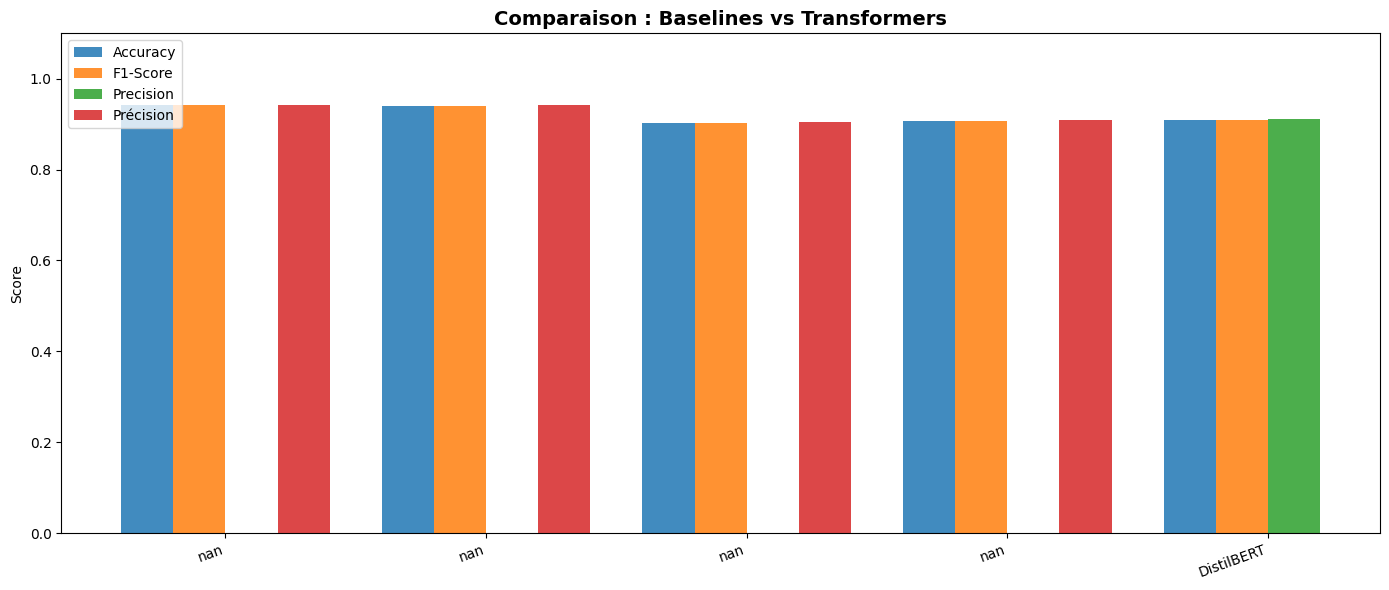

In [26]:
# Visualisation comparative
fig, ax = plt.subplots(figsize=(14, 6))

model_col = 'Modele' if 'Modele' in all_results.columns else 'Modèle'
metric_cols = ['Accuracy', 'F1-Score']
# Check which metric columns exist
available_metrics = [m for m in ['Accuracy', 'F1-Score', 'Precision', 'Précision', 'Rappel', 'Recall'] if m in all_results.columns]
if not available_metrics:
    available_metrics = [c for c in all_results.columns if c != model_col and all_results[c].dtype in ['float64', 'float32']]

x = np.arange(len(all_results))
width = 0.2

for i, metric in enumerate(available_metrics[:4]):
    ax.bar(x + i * width, all_results[metric], width, label=metric, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(all_results[model_col], rotation=20, ha='right')
ax.set_title('Comparaison : Baselines vs Transformers', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.11 Sauvegarde du meilleur modèle

In [27]:
# Sauvegarder le meilleur modele Transformer
best_transformer = max(transformer_results, key=lambda x: x['F1-Score'])
print(f"Meilleur modele Transformer : {best_transformer['Modele']} (F1: {best_transformer['F1-Score']:.4f})")

# Sauvegarder BERT (si entraine)
if bert_model is not None:
    bert_save_dir = os.path.join(MODELS_DIR, 'bert_best')
    os.makedirs(bert_save_dir, exist_ok=True)
    bert_model.save_pretrained(bert_save_dir)
    bert_tokenizer.save_pretrained(bert_save_dir)
    print(f"BERT sauvegarde dans : {bert_save_dir}")

Meilleur modele Transformer : DistilBERT (F1: 0.9099)


In [28]:
# Sauvegarder DistilBERT
db_save_dir = os.path.join(MODELS_DIR, 'distilbert_best')
os.makedirs(db_save_dir, exist_ok=True)
distilbert_model.save_pretrained(db_save_dir)
distilbert_tokenizer.save_pretrained(db_save_dir)
print(f"DistilBERT sauvegarde dans : {db_save_dir}")

# Sauvegarder RoBERTa (si entraine)
if roberta_model is not None:
    rb_save_dir = os.path.join(MODELS_DIR, 'roberta_best')
    os.makedirs(rb_save_dir, exist_ok=True)
    roberta_model.save_pretrained(rb_save_dir)
    roberta_tokenizer.save_pretrained(rb_save_dir)
    print(f"RoBERTa sauvegarde dans : {rb_save_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT sauvegarde dans : ..\models\distilbert_best


In [29]:
# Sauvegarder les resultats complets
all_results.to_csv(os.path.join(MODELS_DIR, 'all_results.csv'), index=False)
print(f"\nResultats sauvegardes dans : {os.path.join(MODELS_DIR, 'all_results.csv')}")


Resultats sauvegardes dans : ..\models\all_results.csv


## 4.12 Conseils pour la gestion de la mémoire GPU

### Bonnes pratiques :

1. **Réduire le batch size** si vous avez des problèmes de mémoire (BATCH_SIZE = 8 ou 4)
2. **Utiliser le gradient accumulation** pour simuler un batch size plus grand :
   ```python
   accumulation_steps = 4
   loss = loss / accumulation_steps
   loss.backward()
   if (step + 1) % accumulation_steps == 0:
       optimizer.step()
       optimizer.zero_grad()
   ```
3. **Utiliser `torch.cuda.empty_cache()`** entre les modèles
4. **Utiliser mixed precision (FP16)** :
   ```python
   from torch.cuda.amp import autocast, GradScaler
   scaler = GradScaler()
   with autocast():
       outputs = model(input_ids, attention_mask, labels=labels)
   ```
5. **Geler les couches inférieures** pour réduire la mémoire requise
6. **Utiliser DistilBERT** comme alternative plus légère

In [30]:
# Libérer la mémoire GPU
if device.type == 'cuda':
    torch.cuda.empty_cache()
    print(f"Mémoire GPU libérée.")
    print(f"Mémoire allouée : {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"Mémoire en cache : {torch.cuda.memory_reserved()/1e9:.2f} GB")

print("\nEntraînement des modèles avancés terminé !")
print("Passez au notebook 05_evaluation.ipynb pour l'évaluation complète.")


Entraînement des modèles avancés terminé !
Passez au notebook 05_evaluation.ipynb pour l'évaluation complète.
